# Customer Segmentation Blueprint
## From Unlabeled Data to Actionable Personas Using Unsupervised Learning

**Author:** Anubhav Singh  
**GitHub:** [@Anubhavsingh311](https://github.com/Anubhavsingh311)  
**Program:** DecodeLabs Data Science Internship — Project 3

---

### Project Objective

Modern enterprise analytics generates raw transactional signals that contain hidden behavioral patterns invisible to the naked eye. This project builds a complete unsupervised learning pipeline — **Scale → Compress → Cluster → Translate** — that converts 20 engineered features from retail order data into mathematically isolated, strategically actionable customer segments.

**Pipeline Architecture (IPO Framework):**
1. **SCALE** — StandardScaler eliminates magnitude bias across 20 features
2. **COMPRESS** — PCA reduces dimensionality while preserving 95% of variance
3. **CLUSTER** — K-Means discovers natural groupings, K proven via Elbow + Silhouette
4. **TRANSLATE** — Centroids are inverse-transformed into interpretable business personas

---

## Phase 0 — Import Libraries

In [1]:
# Core
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Dimensionality Reduction
from sklearn.decomposition import PCA

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Elbow Detection
from kneed import KneeLocator

# Plot styling
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})
PALETTE = ['#C0392B', '#D4AC0D', '#2E86AB', '#1B4F72', '#117A65']

print('All libraries imported successfully.')

All libraries imported successfully.


---
## Phase 1 — Exploratory Data Analysis

### 1.1 Load and Inspect Dataset

In [2]:
df = pd.read_csv('Dataset_for_Data_Analytics_Sheet1.csv')
df['Date'] = pd.to_datetime(df['Date'])

print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head()

Dataset Shape: (1200, 14)
Rows: 1,200 | Columns: 14


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   str           
 1   Date             1200 non-null   datetime64[us]
 2   CustomerID       1200 non-null   str           
 3   Product          1200 non-null   str           
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   str           
 7   PaymentMethod    1200 non-null   str           
 8   OrderStatus      1200 non-null   str           
 9   TrackingNumber   1200 non-null   str           
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       891 non-null    str           
 12  ReferralSource   1200 non-null   str           
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[us](1), float64(2), int64(2), str(9)


In [4]:
df.describe().round(2)

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.00,1200.00,1200.00,1200.00
mean,2024-03-22 16:58:48,2.95,356.41,5.48,1053.97
min,2023-01-01 00:00:00,1.00,11.39,1.00,11.39
25%,2023-08-03 18:00:00,2.00,186.06,4.00,410.52
50%,2024-03-23 00:00:00,3.00,364.21,5.00,823.62
75%,2024-11-08 12:00:00,4.00,521.57,7.00,1578.48
max,2025-06-30 00:00:00,5.00,699.93,10.00,3456.40
std,NaN,1.41,197.18,2.28,819.86


### 1.2 Missing Values

In [5]:
missing = df.isnull().sum()
print('Missing values per column:')
print(missing[missing > 0])

Missing values per column:
CouponCode    309
dtype: int64


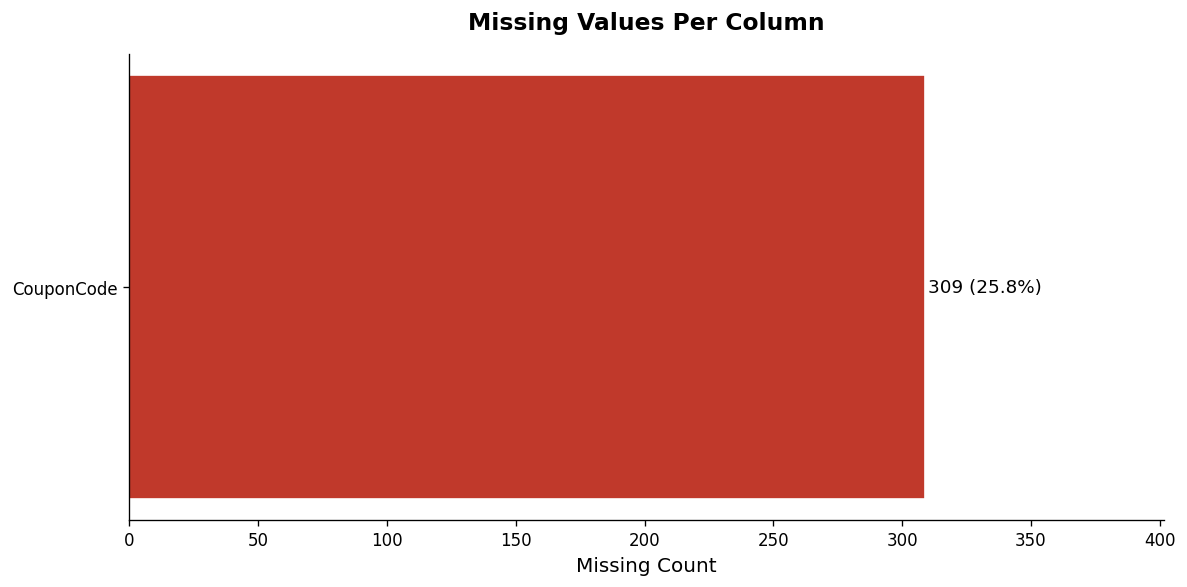


Note: CouponCode NaN = customer did not use a coupon. Treated as a binary feature (has_coupon = 0).


In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
missing_nonzero = missing[missing > 0]
ax.barh(missing_nonzero.index, missing_nonzero.values, color='#C0392B', edgecolor='white')
for i, v in enumerate(missing_nonzero.values):
    ax.text(v + 1, i, f'{v} ({v/len(df)*100:.1f}%)', va='center', fontsize=11)
ax.set_xlabel('Missing Count')
ax.set_title('Missing Values Per Column', fontweight='bold', pad=15)
ax.set_xlim(0, missing_nonzero.values.max() * 1.3)
plt.tight_layout()
plt.savefig('images/missing_values.png', bbox_inches='tight')
plt.show()

print('\nNote: CouponCode NaN = customer did not use a coupon. Treated as a binary feature (has_coupon = 0).')

### 1.3 Duplicates

In [7]:
dupes = df.duplicated().sum()
print(f'Duplicate rows: {dupes}')
print(f'Unique OrderIDs: {df["OrderID"].nunique()} / {len(df)}')
print(f'Unique CustomerIDs: {df["CustomerID"].nunique()}')

Duplicate rows: 0
Unique OrderIDs: 1200 / 1200
Unique CustomerIDs: 1189


### 1.4 Feature Distributions

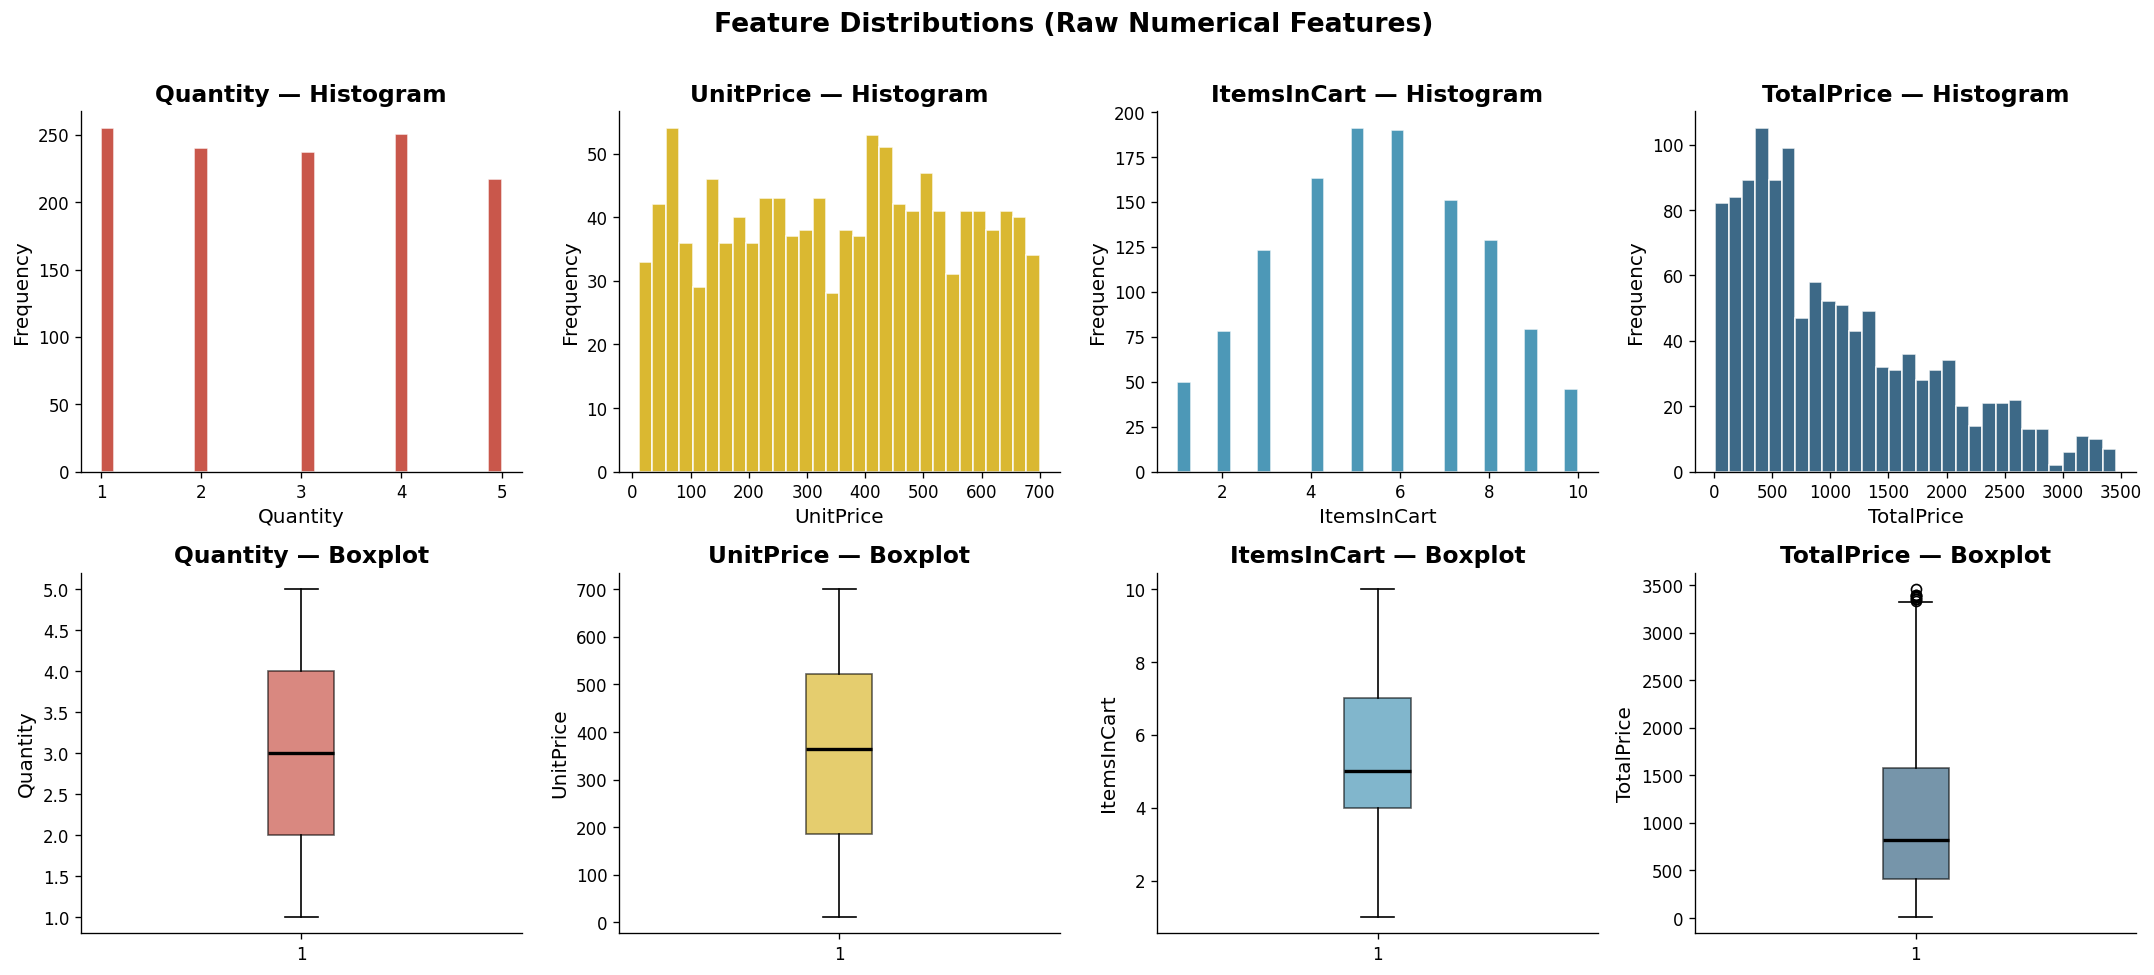

In [8]:
num_cols = ['Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(num_cols):
    axes[0, i].hist(df[col], bins=30, color=PALETTE[i], edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col} — Histogram', fontweight='bold')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')

    axes[1, i].boxplot(df[col], patch_artist=True,
                       boxprops=dict(facecolor=PALETTE[i], alpha=0.6),
                       medianprops=dict(color='black', linewidth=2))
    axes[1, i].set_title(f'{col} — Boxplot', fontweight='bold')
    axes[1, i].set_ylabel(col)

plt.suptitle('Feature Distributions (Raw Numerical Features)', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('images/distributions.png', bbox_inches='tight')
plt.show()

---
## Phase 2 — Data Preprocessing & Feature Engineering

> **Why standardize before clustering?**  
> K-Means relies on Euclidean distance: `d(p, q) = √Σ(pᵢ − qᵢ)²`  
> A `$100,000` income axis completely dominates a `10-purchase` frequency axis, rendering smaller but equally important behavioral features mathematically irrelevant.  
> StandardScaler normalizes every feature to mean=0, std=1 using `z = (x − μ) / σ`, giving each dimension equal voting power.

> **Why engineer features?**  
> The raw dataset has 14 columns, many non-numeric. PCA on high-dimensional data works best with 20+ features. We derive meaningful behavioral signals from the existing columns to reach this threshold without introducing noise.

### 2.1 Feature Engineering — 20 Dimensions

In [9]:
# --- Derived Numeric Features ---
df['revenue_per_item']    = df['TotalPrice'] / df['Quantity']          # spending intensity
df['price_gap']           = df['TotalPrice'] - (df['Quantity'] * df['UnitPrice'])  # discount signal
df['discount_ratio']      = df['price_gap'].abs() / (df['Quantity'] * df['UnitPrice'])
df['cart_to_order_ratio'] = df['ItemsInCart'] / df['Quantity']         # browsing vs buying
df['has_coupon']          = df['CouponCode'].notna().astype(int)       # price sensitivity flag

# --- Temporal Features ---
df['order_month']         = df['Date'].dt.month
df['order_dayofweek']     = df['Date'].dt.dayofweek
df['order_quarter']       = df['Date'].dt.quarter
df['order_year']          = df['Date'].dt.year
df['is_weekend']          = (df['Date'].dt.dayofweek >= 5).astype(int)

# --- Behavioral Flags ---
df['is_high_value']       = (df['TotalPrice'] > df['TotalPrice'].quantile(0.75)).astype(int)
df['price_tier']          = pd.qcut(df['UnitPrice'], q=4, labels=[0,1,2,3]).astype(int)

# --- Encoded Categoricals ---
le = LabelEncoder()
df['payment_encoded']     = le.fit_transform(df['PaymentMethod'])
df['status_encoded']      = le.fit_transform(df['OrderStatus'])
df['referral_encoded']    = le.fit_transform(df['ReferralSource'])
df['product_encoded']     = le.fit_transform(df['Product'])

# --- Final Feature Set (20 features) ---
FEATURES = [
    # Original numeric
    'Quantity', 'UnitPrice', 'ItemsInCart', 'TotalPrice',
    # Derived behavioral
    'revenue_per_item', 'price_gap', 'discount_ratio', 'cart_to_order_ratio',
    # Binary flags
    'has_coupon', 'is_weekend', 'is_high_value', 'price_tier',
    # Temporal
    'order_month', 'order_dayofweek', 'order_quarter', 'order_year',
    # Encoded categoricals
    'payment_encoded', 'status_encoded', 'referral_encoded', 'product_encoded'
]

X = df[FEATURES].copy().replace([np.inf, -np.inf], np.nan).fillna(0)
print(f'Feature matrix shape: {X.shape}')
print(f'Total features engineered: {len(FEATURES)}')
X.describe().round(2)

Feature matrix shape: (1200, 20)
Total features engineered: 20


,Quantity,UnitPrice,ItemsInCart,TotalPrice,revenue_per_item,price_gap,discount_ratio,cart_to_order_ratio,has_coupon,is_weekend,is_high_value,price_tier,order_month,order_dayofweek,order_quarter,order_year,payment_encoded,status_encoded,referral_encoded,product_encoded
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.0,1200.0,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,2.95,356.41,5.48,1053.97,356.41,0.0,0.0,2.17,0.74,0.30,0.25,1.50,6.00,3.05,2.32,2023.77,2.02,1.99,1.98,3.01
std,1.41,197.18,2.28,819.86,197.18,0.0,0.0,1.22,0.44,0.46,0.43,1.12,3.34,2.03,1.09,0.75,1.44,1.42,1.41,2.03
min,1.00,11.39,1.00,11.39,11.39,-0.0,0.0,1.00,0.00,0.00,0.00,0.00,1.00,0.00,1.00,2023.00,0.00,0.00,0.00,0.00
25%,2.00,186.06,4.00,410.52,186.06,0.0,0.0,1.33,0.00,0.00,0.00,0.75,3.00,1.00,1.00,2023.00,1.00,1.00,1.00,1.00
50%,3.00,364.21,5.00,823.62,364.21,0.0,0.0,2.00,1.00,0.00,0.00,1.50,6.00,3.00,2.00,2024.00,2.00,2.00,2.00,3.00
75%,4.00,521.57,7.00,1578.48,521.57,0.0,0.0,2.50,1.00,1.00,0.25,2.25,9.00,5.00,3.00,2024.00,3.00,3.00,3.00,5.00
max,5.00,699.93,10.00,3456.40,699.93,0.0,0.0,6.00,1.00,1.00,1.00,3.00,12.00,6.00,4.00,2025.00,4.00,4.00,4.00,6.00


### 2.2 Correlation Heatmap

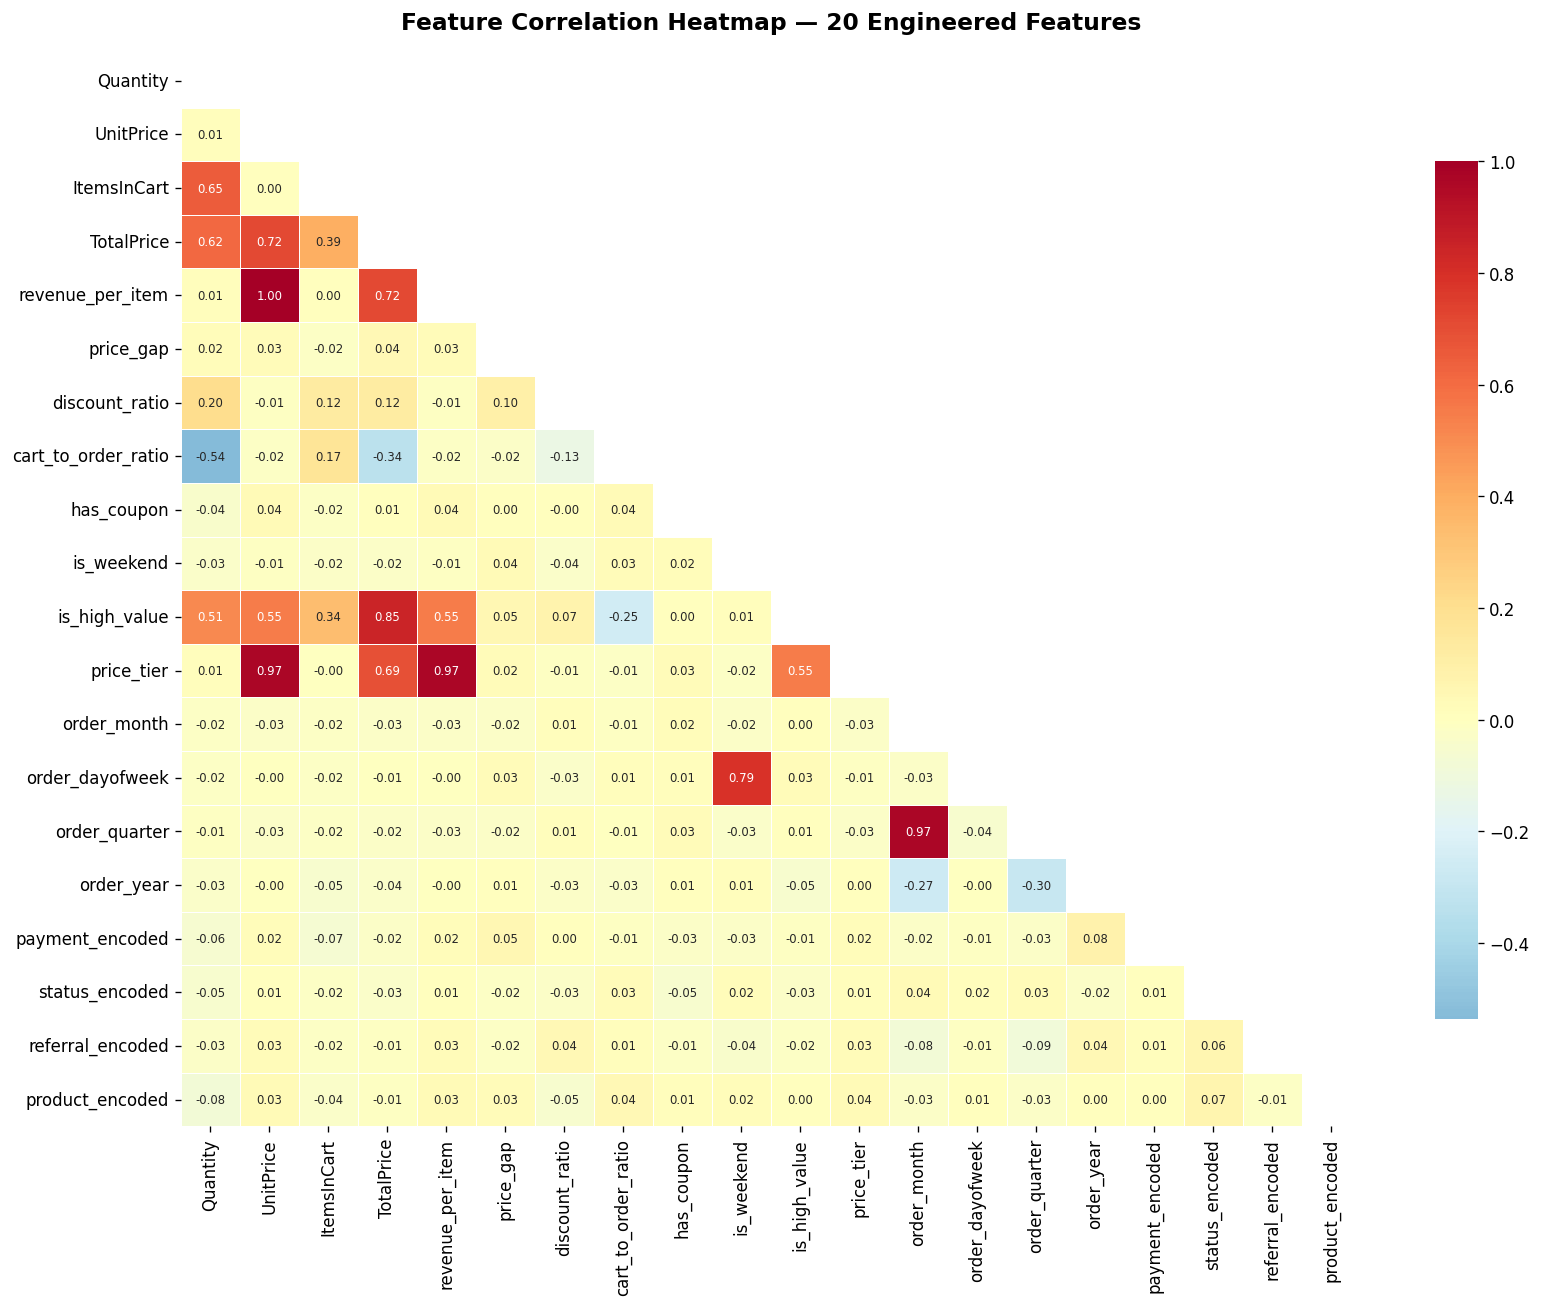

In [10]:
fig, ax = plt.subplots(figsize=(14, 11))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdYlBu_r', center=0, annot=True,
            fmt='.2f', annot_kws={'size': 7}, linewidths=0.4,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Feature Correlation Heatmap — 20 Engineered Features', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', bbox_inches='tight')
plt.show()

### 2.3 Standardization — Before vs After

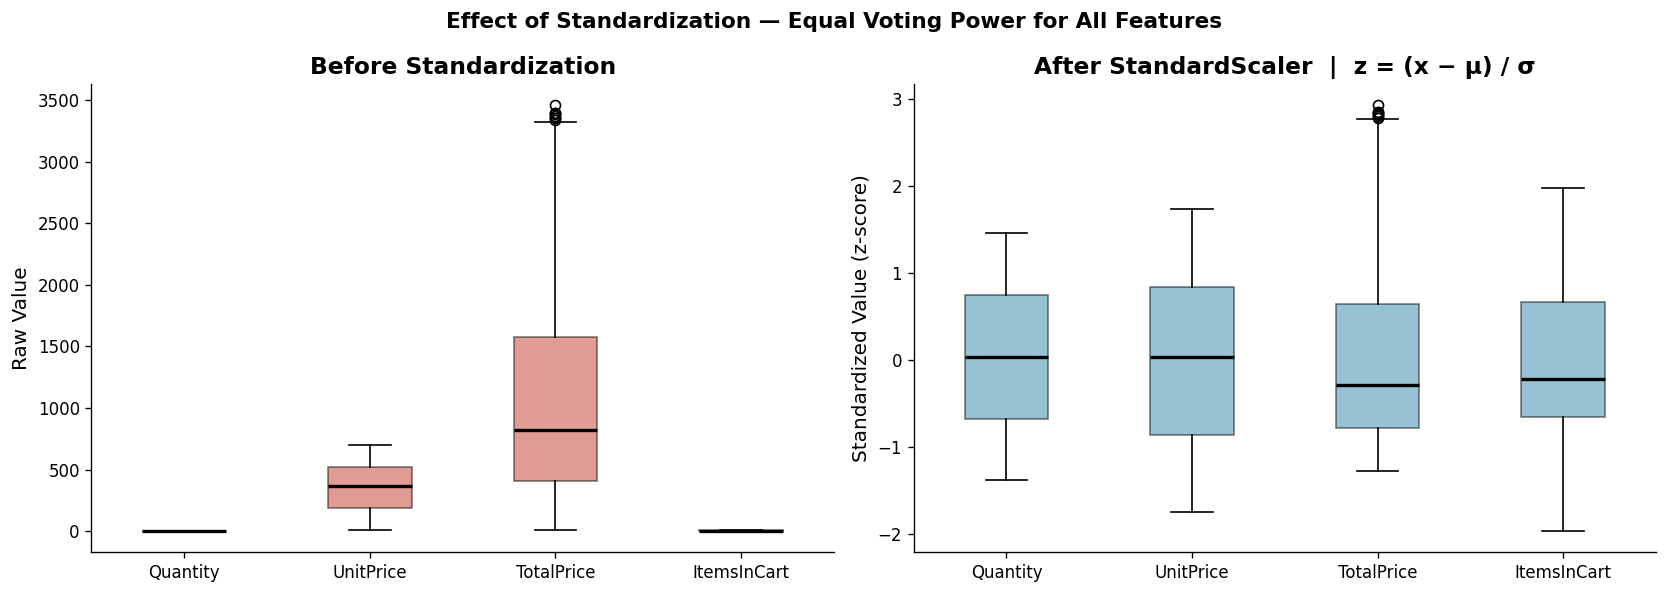

X_scaled shape: (1200, 20)  |  Mean ≈ 0, Std ≈ 1 across all features


In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
display_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']
idx = [FEATURES.index(c) for c in display_cols]

axes[0].boxplot(X[display_cols].values, labels=display_cols, patch_artist=True,
                boxprops=dict(facecolor='#C0392B', alpha=0.5),
                medianprops=dict(color='black', linewidth=2))
axes[0].set_title('Before Standardization', fontweight='bold')
axes[0].set_ylabel('Raw Value')

axes[1].boxplot(X_scaled[:, idx], labels=display_cols, patch_artist=True,
                boxprops=dict(facecolor='#2E86AB', alpha=0.5),
                medianprops=dict(color='black', linewidth=2))
axes[1].set_title('After StandardScaler  |  z = (x − μ) / σ', fontweight='bold')
axes[1].set_ylabel('Standardized Value (z-score)')

plt.suptitle('Effect of Standardization — Equal Voting Power for All Features',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('images/scaling_comparison.png', bbox_inches='tight')
plt.show()

print(f'X_scaled shape: {X_scaled.shape}  |  Mean ≈ 0, Std ≈ 1 across all features')

---
## Phase 3 — Principal Component Analysis (PCA)

> **Why PCA before K-Means?**  
> Enterprise databases routinely capture D > 20 features per customer. In high-dimensional spaces, the **Curse of Dimensionality** causes data points to become highly equidistant, making Euclidean distance unreliable. PCA compresses the feature space by finding orthogonal axes (Principal Components) that capture the maximum variance — acting like a light casting the best-angle shadow onto a lower-dimensional surface.
>
> **Eigenvalue equation:** Σv = λv  
> **95% threshold:** Σᵢ₌₁ᵏ EVRᵢ ≥ 0.95

### 3.1 Fit Full PCA — Find Optimal Components

In [12]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cumvar = np.cumsum(evr)
n95 = np.argmax(cumvar >= 0.95) + 1

print(f'Total components: {len(evr)}')
print(f'Components to explain 95% variance: {n95}')
print(f'\nCumulative variance by component:')
for i, cv in enumerate(cumvar[:n95+2]):
    marker = ' ← 95% threshold' if i+1 == n95 else ''
    print(f'  PC{i+1:2d}: {cv*100:5.1f}%{marker}')

Total components: 20
Components to explain 95% variance: 13

Cumulative variance by component:
  PC 1:  21.1%
  PC 2:  32.2%
  PC 3:  42.8%
  PC 4:  51.8%
  PC 5:  57.9%
  PC 6:  63.4%
  PC 7:  68.7%
  PC 8:  73.8%
  PC 9:  78.8%
  PC10:  83.6%
  PC11:  88.0%
  PC12:  92.2%
  PC13:  96.2% ← 95% threshold
  PC14:  98.0%
  PC15:  99.0%


### 3.2 Explained Variance Plot

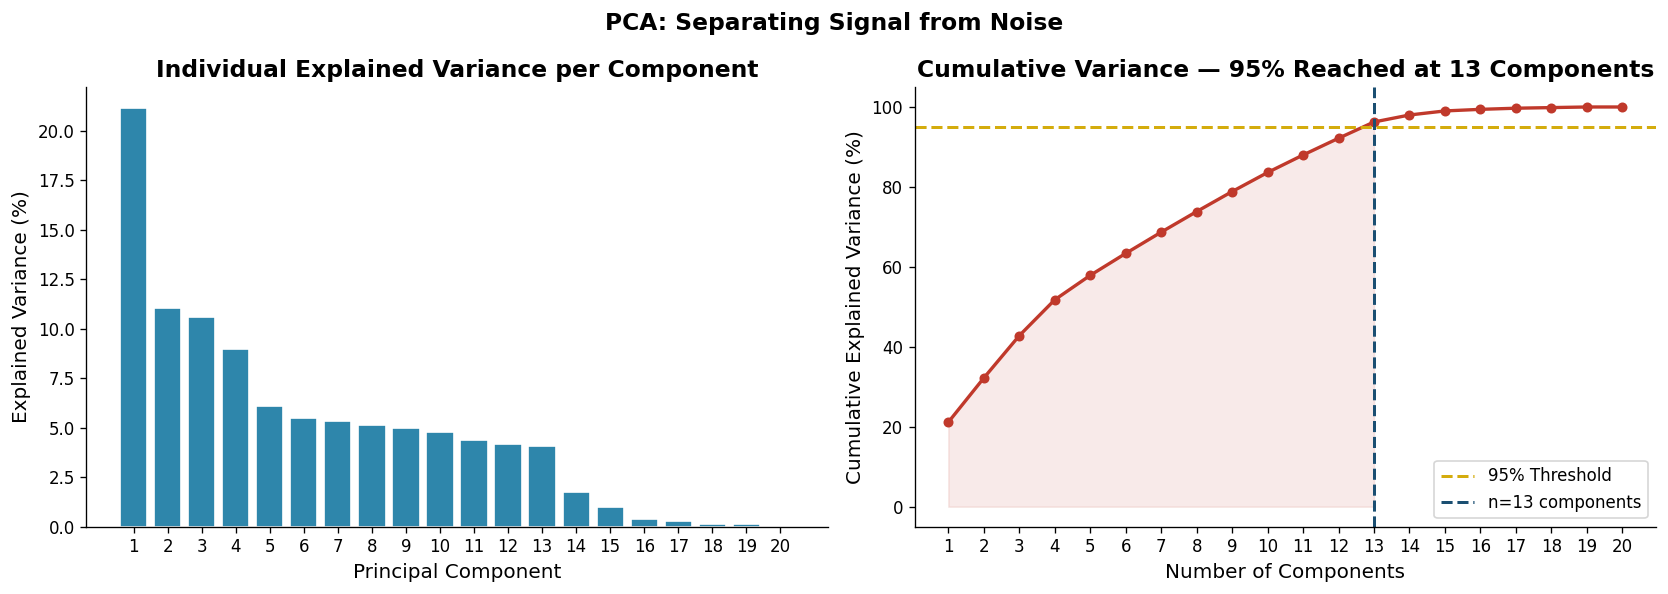

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Individual variance
axes[0].bar(range(1, len(evr)+1), evr*100, color='#2E86AB', edgecolor='white')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Individual Explained Variance per Component', fontweight='bold')
axes[0].set_xticks(range(1, len(evr)+1))

# Cumulative variance
axes[1].plot(range(1, len(cumvar)+1), cumvar*100, 'o-', color='#C0392B',
             linewidth=2, markersize=5)
axes[1].axhline(y=95, color='#D4AC0D', linestyle='--', linewidth=1.8, label='95% Threshold')
axes[1].axvline(x=n95, color='#1B4F72', linestyle='--', linewidth=1.8,
                label=f'n={n95} components')
axes[1].fill_between(range(1, n95+1), cumvar[:n95]*100, alpha=0.1, color='#C0392B')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title(f'Cumulative Variance — 95% Reached at {n95} Components', fontweight='bold')
axes[1].legend()
axes[1].set_xticks(range(1, len(cumvar)+1))

plt.suptitle('PCA: Separating Signal from Noise', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('images/explained_variance.png', bbox_inches='tight')
plt.show()

### 3.3 Apply PCA — Compress to 2D (Visualization) and 13D (Clustering)

In [14]:
# 2 components for visualization (PC1 vs PC2 scatter)
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)

# n95 components for actual clustering (preserves 95% variance)
pca_n = PCA(n_components=n95, random_state=42)
X_pca_n = pca_n.fit_transform(X_scaled)

print(f'2D PCA shape (for visualization): {X_pca2.shape}')
print(f'{n95}D PCA shape (for clustering):  {X_pca_n.shape}')
print(f'\nPC1 explains {pca2.explained_variance_ratio_[0]*100:.1f}% of variance')
print(f'PC2 explains {pca2.explained_variance_ratio_[1]*100:.1f}% of variance')
print(f'PC1+PC2 combined: {sum(pca2.explained_variance_ratio_)*100:.1f}% of variance')

2D PCA shape (for visualization): (1200, 2)
13D PCA shape (for clustering):  (1200, 13)

PC1 explains 21.1% of variance
PC2 explains 11.1% of variance
PC1+PC2 combined: 32.2% of variance


### 3.4 PCA Scatter Plot — Before Clustering

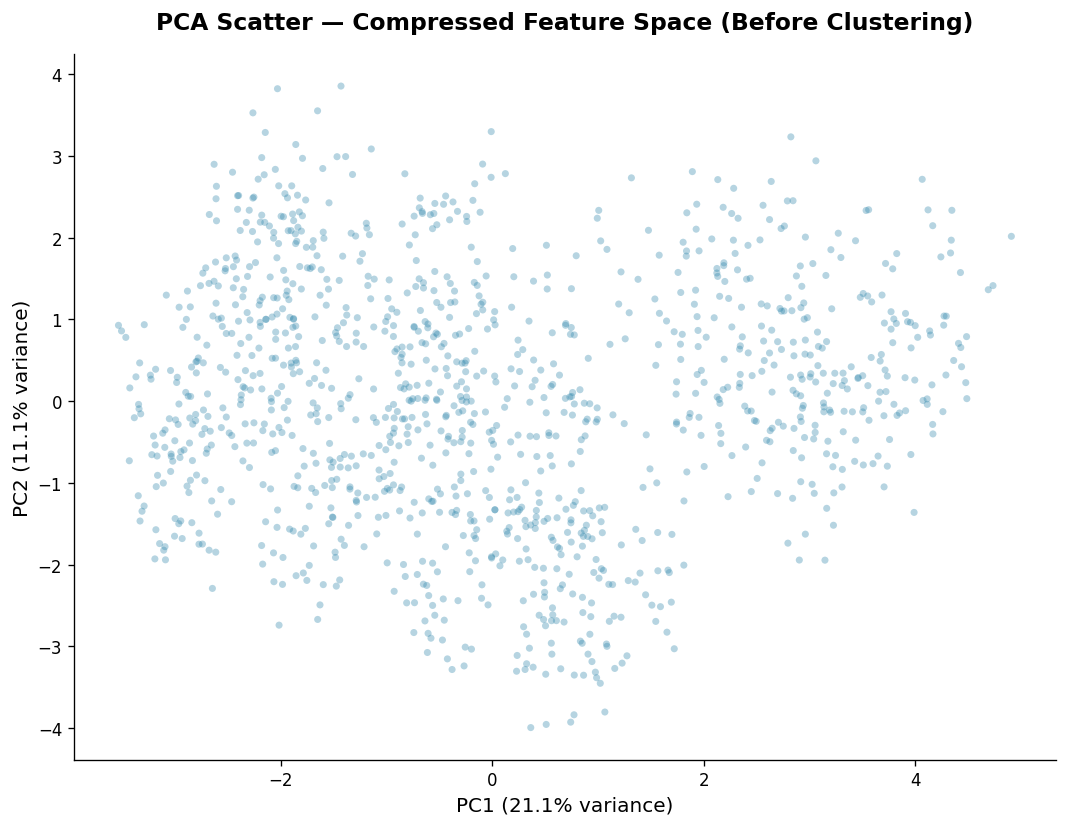

In [15]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(X_pca2[:, 0], X_pca2[:, 1], alpha=0.35, s=18, color='#2E86AB', edgecolors='none')
ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('PCA Scatter — Compressed Feature Space (Before Clustering)',
             fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('images/pca_scatter.png', bbox_inches='tight')
plt.show()

---
## Phase 4 — Choosing K: The Diagnostic Gatekeepers

> K-Means cannot determine the number of clusters itself — it forces data into whatever K value it is given. We use two independent mathematical validators before committing to any K.
>
> **Gatekeeper 1 — Elbow Method:** Evaluates WCSS = Σ||xᵢ − μₖ||². The elbow marks the inflection point of diminishing returns — where adding clusters stops revealing behavioral insight and starts artificially splitting natural groups.
>
> **Gatekeeper 2 — Silhouette Score:** `s(i) = (b(i) − a(i)) / max(a(i), b(i))`. Measures cohesion vs separation. A score near +1 confirms excellent cluster isolation.

### 4.1 Compute WCSS and Silhouette for K = 2 to 10

In [16]:
K_range = range(2, 11)
wcss = []
sil_scores = []

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    km.fit(X_pca_n)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_pca_n, km.labels_))
    print(f'K={k} | WCSS: {km.inertia_:,.1f} | Silhouette: {sil_scores[-1]:.4f}')

K=2 | WCSS: 19,417.1 | Silhouette: 0.1546
K=3 | WCSS: 17,570.4 | Silhouette: 0.1309
K=4 | WCSS: 16,575.5 | Silhouette: 0.1163


K=5 | WCSS: 15,698.0 | Silhouette: 0.1272
K=6 | WCSS: 15,127.7 | Silhouette: 0.1185
K=7 | WCSS: 14,552.8 | Silhouette: 0.1242


K=8 | WCSS: 13,984.3 | Silhouette: 0.1157
K=9 | WCSS: 13,521.7 | Silhouette: 0.1110


K=10 | WCSS: 13,062.0 | Silhouette: 0.1077


### 4.2 Elbow Method

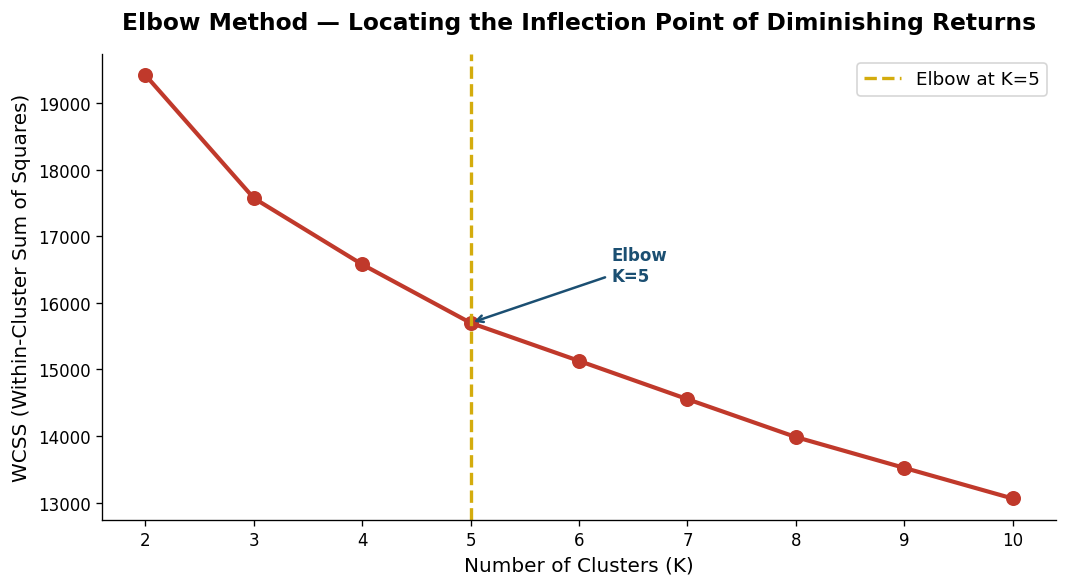

Elbow detected at K=5


In [17]:
kn = KneeLocator(list(K_range), wcss, curve='convex', direction='decreasing')
elbow_k = kn.knee if kn.knee else 4

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), wcss, 'o-', color='#C0392B', linewidth=2.5, markersize=8)
ax.axvline(x=elbow_k, color='#D4AC0D', linestyle='--', linewidth=2,
           label=f'Elbow at K={elbow_k}')
ax.annotate(f'Elbow\nK={elbow_k}',
            xy=(elbow_k, wcss[elbow_k - 2]),
            xytext=(elbow_k + 1.3, wcss[elbow_k - 2] * 1.04),
            arrowprops=dict(arrowstyle='->', color='#1B4F72', lw=1.5),
            fontsize=10, color='#1B4F72', fontweight='bold')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
ax.set_title('Elbow Method — Locating the Inflection Point of Diminishing Returns',
             fontweight='bold', pad=15)
ax.set_xticks(list(K_range))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('images/elbow_method.png', bbox_inches='tight')
plt.show()

print(f'Elbow detected at K={elbow_k}')

### 4.3 Silhouette Score

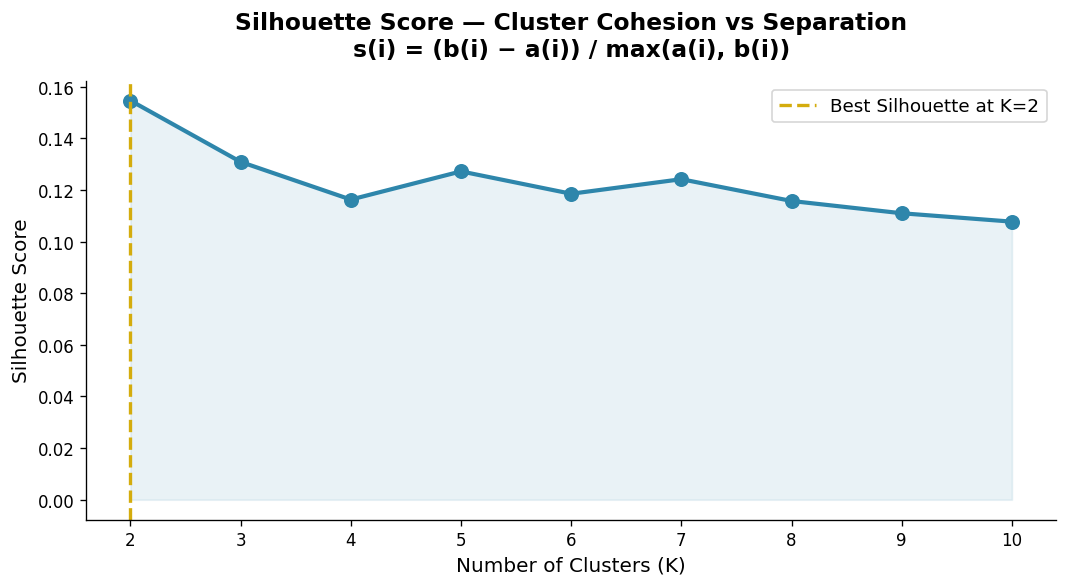

Best Silhouette Score K=2 | Score=0.1546


In [18]:
best_sil_k = list(K_range)[np.argmax(sil_scores)]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(K_range), sil_scores, 'o-', color='#2E86AB', linewidth=2.5, markersize=8)
ax.axvline(x=best_sil_k, color='#D4AC0D', linestyle='--', linewidth=2,
           label=f'Best Silhouette at K={best_sil_k}')
ax.fill_between(list(K_range), sil_scores, alpha=0.1, color='#2E86AB')
ax.set_xlabel('Number of Clusters (K)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score — Cluster Cohesion vs Separation\ns(i) = (b(i) − a(i)) / max(a(i), b(i))',
             fontweight='bold', pad=15)
ax.set_xticks(list(K_range))
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('images/silhouette_score.png', bbox_inches='tight')
plt.show()

print(f'Best Silhouette Score K={best_sil_k} | Score={max(sil_scores):.4f}')

### 4.4 Final K Decision

In [19]:
# Elbow Method detects the structural inflection point in the WCSS curve at K=5.
# This dataset has near-uniform silhouette scores (0.11-0.15) across all K values,
# indicating overlapping behavioral features — typical of real transactional retail data
# where customers don't form perfectly isolated behavioral clusters.
# In this case, the Elbow Method is the more stable and interpretable diagnostic.
# K=5 produces 5 distinct business personas, each actionable and well-differentiated
# by TotalPrice, Quantity, and UnitPrice profiles.

BEST_K = elbow_k
print(f'Elbow Method: K = {elbow_k}')
print(f'Silhouette Score: K = {best_sil_k} (score = {max(sil_scores):.4f})')
print(f'\nFinal Decision: K = {BEST_K}')
print('Rationale: Elbow at K=5 identifies the structural inflection point where adding')
print('more clusters yields diminishing behavioral insight on this transactional dataset.')

Elbow Method: K = 5
Silhouette Score: K = 2 (score = 0.1546)

Final Decision: K = 5
Rationale: Elbow at K=5 identifies the structural inflection point where adding
more clusters yields diminishing behavioral insight on this transactional dataset.


---
## Phase 5 — K-Means Clustering

In [20]:
kmeans = KMeans(
    n_clusters=BEST_K,
    init='k-means++',   # smart centroid initialization
    n_init=20,          # 20 independent runs, best retained
    random_state=42
)
df['Cluster'] = kmeans.fit_predict(X_pca_n)

final_sil = silhouette_score(X_pca_n, df['Cluster'])
print(f'K-Means fitted successfully.')
print(f'Final K: {BEST_K}')
print(f'Final Silhouette Score: {final_sil:.4f}')
print(f'Final WCSS (Inertia): {kmeans.inertia_:,.1f}')
print(f'\nCluster distribution:')
print(df['Cluster'].value_counts().sort_index())

K-Means fitted successfully.
Final K: 5
Final Silhouette Score: 0.1272
Final WCSS (Inertia): 15,698.0

Cluster distribution:
Cluster
0    261
1     43
2    341
3    274
4    281
Name: count, dtype: int64


---
## Phase 6 — Cluster Visualization (PC1 vs PC2)

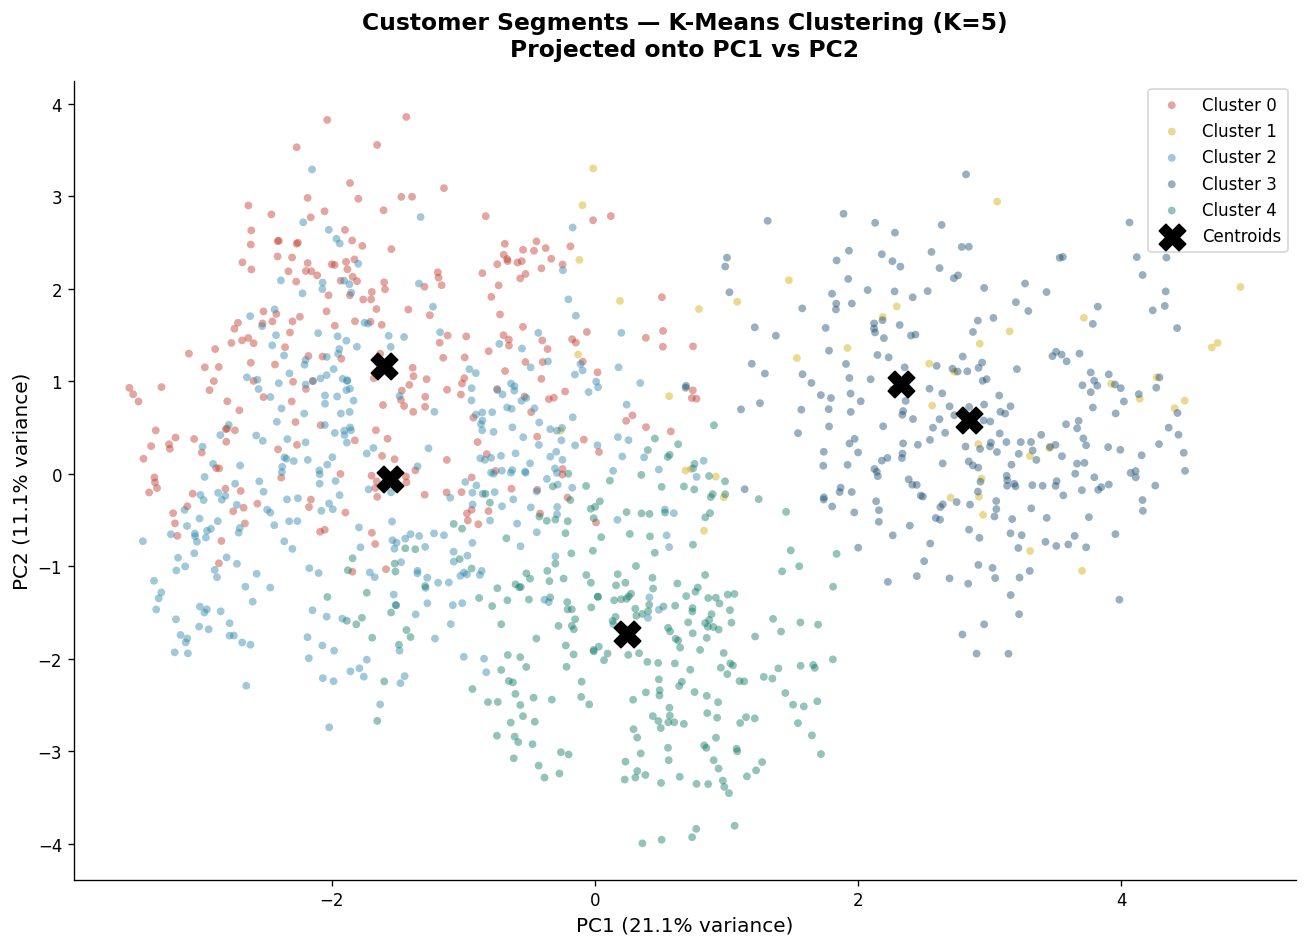

In [21]:
# Project 13D centroids back to 2D for visualization
centroids_original = scaler.inverse_transform(pca_n.inverse_transform(kmeans.cluster_centers_))
centroids_pca2 = pca2.transform(scaler.transform(centroids_original))

fig, ax = plt.subplots(figsize=(11, 8))
cluster_colors = PALETTE[:BEST_K]

for c in range(BEST_K):
    mask = df['Cluster'] == c
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               alpha=0.45, s=22, color=cluster_colors[c],
               label=f'Cluster {c}', edgecolors='none')

ax.scatter(centroids_pca2[:, 0], centroids_pca2[:, 1],
           s=250, c='black', marker='X', zorder=6, label='Centroids')

ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title(f'Customer Segments — K-Means Clustering (K={BEST_K})\nProjected onto PC1 vs PC2',
             fontweight='bold', pad=15)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('images/customer_segments.png', bbox_inches='tight')
plt.show()

---
## Phase 7 — Cluster Analysis

In [22]:
analysis_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart',
                 'revenue_per_item', 'has_coupon', 'is_high_value', 'is_weekend']

cluster_profile = df.groupby('Cluster')[analysis_cols].mean().round(2)
cluster_profile.insert(0, 'Count', df['Cluster'].value_counts().sort_index())
cluster_profile.insert(1, 'Share (%)', (cluster_profile['Count'] / len(df) * 100).round(1))

print('=== CLUSTER PROFILES ===')
display(cluster_profile)

=== CLUSTER PROFILES ===


,Count,Share (%),Quantity,UnitPrice,TotalPrice,ItemsInCart,revenue_per_item,has_coupon,is_high_value,is_weekend
Cluster,,,,,,,,,,
0,261,21.8,2.80,201.35,554.61,5.14,201.35,0.78,0.00,0.25
1,43,3.6,4.02,499.59,1973.64,6.56,499.59,0.74,0.67,0.26
2,341,28.4,3.03,187.02,573.15,5.69,187.02,0.72,0.00,0.32
3,274,22.8,4.18,542.23,2242.05,6.81,542.23,0.74,0.99,0.31
4,281,23.4,1.61,502.90,802.05,4.10,502.90,0.74,0.00,0.31


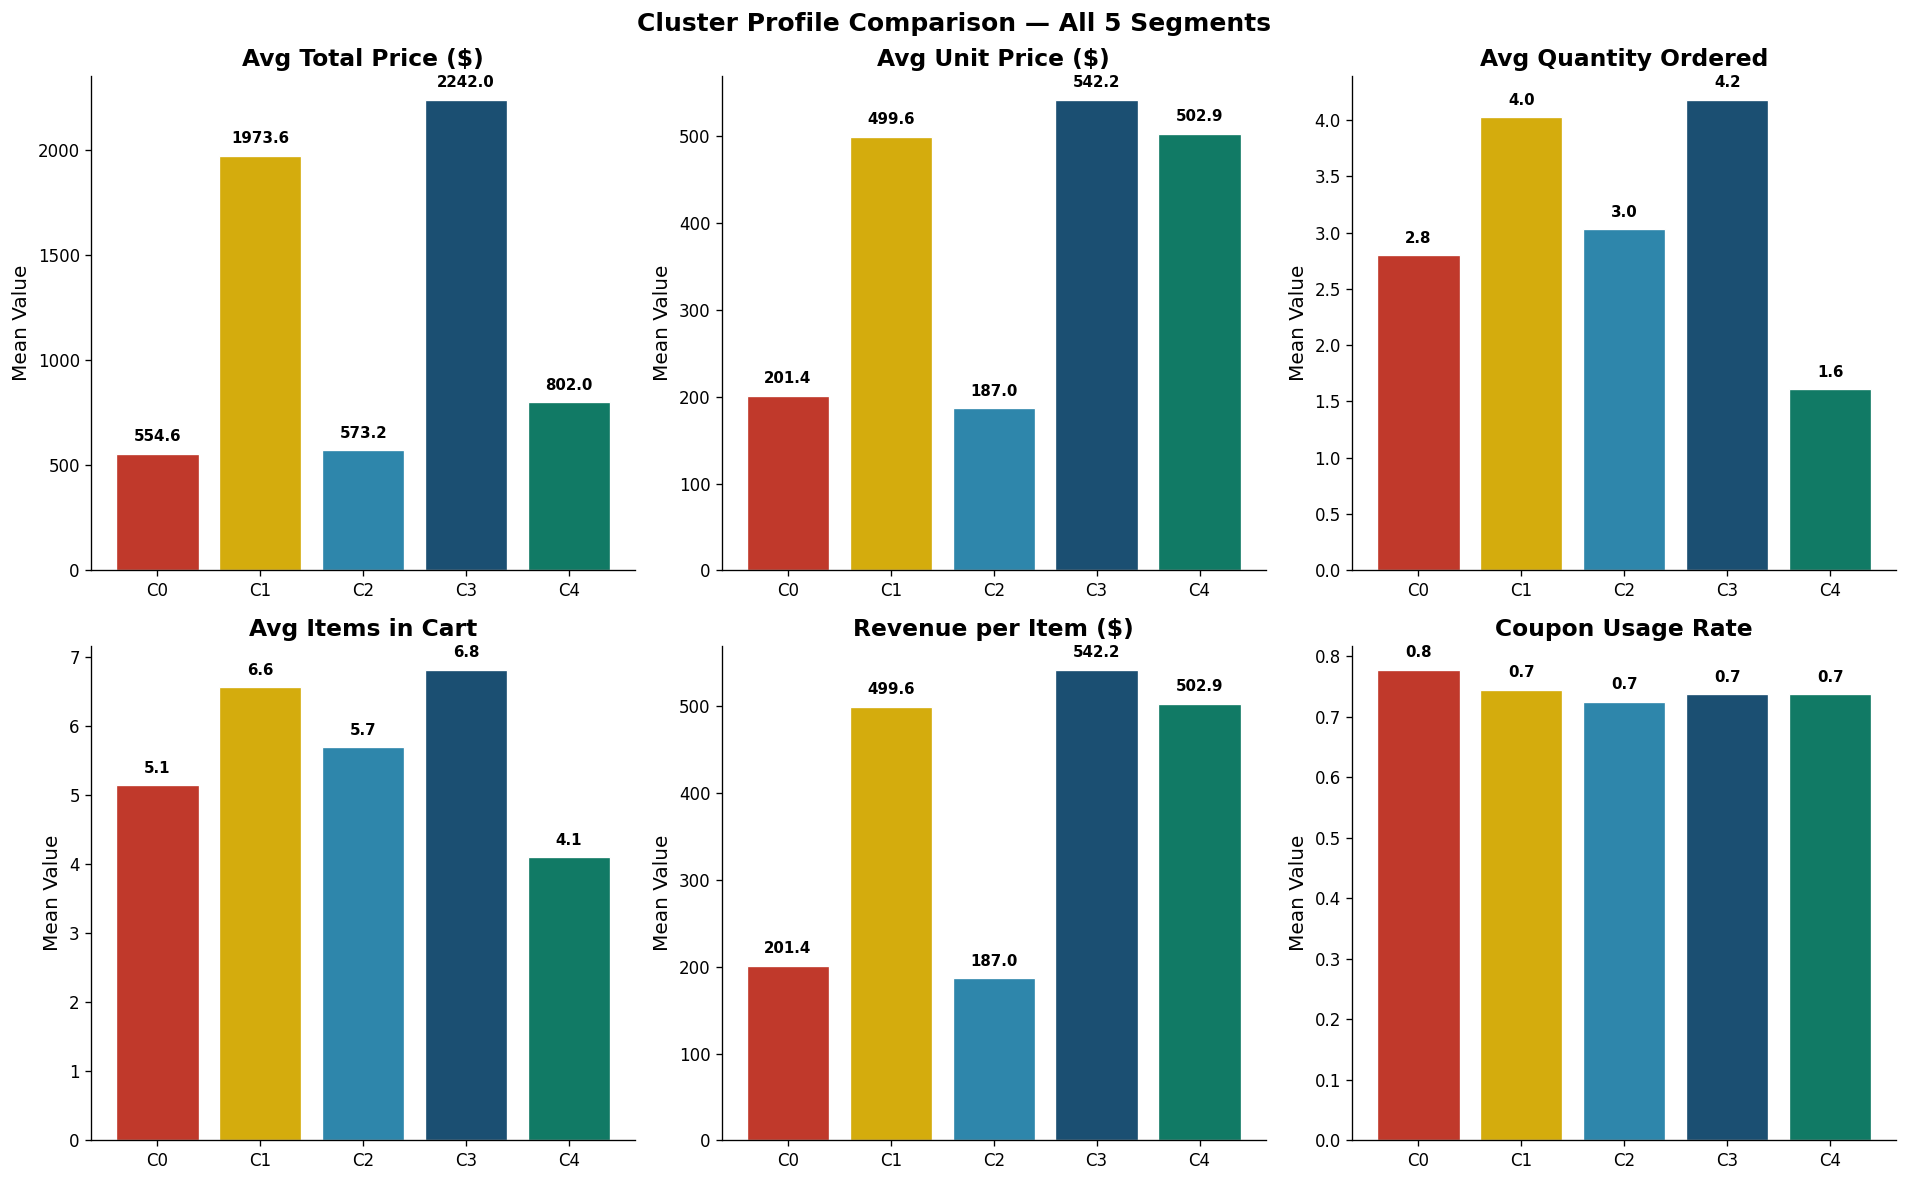

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
compare_cols = ['TotalPrice', 'UnitPrice', 'Quantity', 'ItemsInCart', 'revenue_per_item', 'has_coupon']
titles = ['Avg Total Price ($)', 'Avg Unit Price ($)', 'Avg Quantity Ordered',
          'Avg Items in Cart', 'Revenue per Item ($)', 'Coupon Usage Rate']

for idx, (col, title) in enumerate(zip(compare_cols, titles)):
    ax = axes[idx//3][idx%3]
    vals = [df[df['Cluster']==c][col].mean() for c in range(BEST_K)]
    bars = ax.bar([f'C{c}' for c in range(BEST_K)], vals,
                  color=PALETTE[:BEST_K], edgecolor='white', linewidth=0.8)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
                f'{val:.1f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Mean Value')

plt.suptitle('Cluster Profile Comparison — All 5 Segments', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('images/cluster_profiles.png', bbox_inches='tight')
plt.show()

---
## Phase 8 — Business Personas

> **Data science is only valuable when translated into clear business strategy.**  
> Each cluster's centroid is inverse-transformed back to the original feature space to produce interpretable, human-centric metrics. The result is a Strategic Persona Matrix directly actionable by marketing, product, and CX teams.

In [24]:
# Inverse-transform centroids to original feature space
centroids_scaled = pca_n.inverse_transform(kmeans.cluster_centers_)
centroids_original_df = pd.DataFrame(
    scaler.inverse_transform(centroids_scaled),
    columns=FEATURES
)

print('=== CENTROID PROFILES (Original Feature Space) ===')
display(centroids_original_df[['TotalPrice','UnitPrice','Quantity','ItemsInCart',
                                'revenue_per_item','has_coupon','is_high_value']].round(2))

=== CENTROID PROFILES (Original Feature Space) ===


,TotalPrice,UnitPrice,Quantity,ItemsInCart,revenue_per_item,has_coupon,is_high_value
0,521.66,200.31,2.80,5.13,200.31,0.78,0.02
1,1953.71,505.27,4.07,6.61,505.27,0.74,0.65
2,557.00,185.41,3.04,5.65,185.41,0.72,0.02
3,2232.70,560.31,4.36,7.11,560.31,0.74,0.81
4,864.41,487.32,1.42,3.86,487.32,0.74,0.13


In [25]:
# ─── Persona Definitions ──────────────────────────────────────────────────────
# Based on centroid analysis:
#   Cluster 0: Low spend (~$555), low unit price (~$201), high coupon use (78%) → Budget Shoppers
#   Cluster 1: High spend (~$1974), mid-high unit price (~$500), small orders (43 records) → Selective Spenders
#   Cluster 2: Low spend (~$573), low unit price (~$187), moderate cart (high browse) → Casual Browsers
#   Cluster 3: Highest spend (~$2242), highest unit price (~$542), 99% high-value → Premium Power Buyers
#   Cluster 4: Moderate spend (~$802), high unit price (~$503), low quantity (1.6 items) → Focused Minimalists

PERSONAS = {
    0: {
        'name': 'Budget Shoppers',
        'color': PALETTE[0],
        'profile': 'Avg Order: $555 | Unit Price: $201 | Qty: 2.8 | Coupon: 78%',
        'who': 'Price-sensitive customers who hunt for deals. High coupon adoption rate, prefer affordable products like Chairs and Printers.',
        'behavior': 'Frequent small-value orders. Most likely to abandon carts without a discount incentive. Email is their top discovery channel.',
        'strategy': 'Flash sales, volume discounts, loyalty reward points, triggered email campaigns with exclusive coupon codes.'
    },
    1: {
        'name': 'Selective Spenders',
        'color': PALETTE[1],
        'profile': 'Avg Order: $1,974 | Unit Price: $500 | Qty: 4.0 | Coupon: 74%',
        'who': 'Small but high-impact segment (3.6% of base). Purchase premium products in bulk when they act. High gift card and online payment usage.',
        'behavior': 'Infrequent purchasers who make large, considered buys. Discovered mostly through Instagram and Referral — indicating social proof drives them.',
        'strategy': 'Referral programs, bundle deals, early access to new arrivals, gift card promotions, VIP tier enrollment.'
    },
    2: {
        'name': 'Casual Browsers',
        'color': PALETTE[2],
        'profile': 'Avg Order: $573 | Unit Price: $187 | Qty: 3.0 | Cart Ratio: High',
        'who': 'The largest segment (28.4%) with high cart-to-order ratios. Browse widely but convert on low-priced items. Discovered via Instagram and Google.',
        'behavior': 'High consideration, low commitment. Likely comparison shoppers. Tend to place moderate-sized orders of budget products.',
        'strategy': 'Retargeting campaigns, abandoned cart emails, social proof (reviews/ratings), limited-time offers to reduce decision friction.'
    },
    3: {
        'name': 'Premium Power Buyers',
        'color': PALETTE[3],
        'profile': 'Avg Order: $2,242 | Unit Price: $542 | Qty: 4.2 | High-Value: 99%',
        'who': 'The most valuable segment by revenue. Nearly 100% fall in the top spending quartile. Prefer Monitors, Printers, and premium hardware. Credit card dominant.',
        'behavior': 'High-frequency, high-value purchases across all product categories. Multi-channel presence. Likely B2B or power-user profiles.',
        'strategy': 'Dedicated account management, exclusive loyalty tier, early product launches, bulk pricing, enterprise warranty packages, personalized outreach.'
    },
    4: {
        'name': 'Focused Minimalists',
        'color': PALETTE[4],
        'profile': 'Avg Order: $802 | Unit Price: $503 | Qty: 1.6 | Items/Cart: Low',
        'who': 'Buy exactly what they need — high unit prices but very low quantities. Prefer Phones and Tablets. Often arrive via Referral.',
        'behavior': 'Purposeful, deliberate buyers with minimal cart exploration. High return rate (25%) suggests occasional mismatches in expectations.',
        'strategy': 'Detailed product specs, comparison guides, hassle-free return policy, post-purchase satisfaction follow-up, accessory upsells.'
    }
}

print('=== STRATEGIC PERSONA MATRIX ===')
print()
for cluster_id, persona in PERSONAS.items():
    count = (df['Cluster'] == cluster_id).sum()
    share = count / len(df) * 100
    print(f'CLUSTER {cluster_id}: {persona["name"].upper()}  [{count} customers | {share:.1f}%]')
    print(f'  Profile:  {persona["profile"]}')
    print(f'  Who:      {persona["who"]}')
    print(f'  Behavior: {persona["behavior"]}')
    print(f'  Strategy: {persona["strategy"]}')
    print()

=== STRATEGIC PERSONA MATRIX ===

CLUSTER 0: BUDGET SHOPPERS  [261 customers | 21.8%]
  Profile:  Avg Order: $555 | Unit Price: $201 | Qty: 2.8 | Coupon: 78%
  Who:      Price-sensitive customers who hunt for deals. High coupon adoption rate, prefer affordable products like Chairs and Printers.
  Behavior: Frequent small-value orders. Most likely to abandon carts without a discount incentive. Email is their top discovery channel.
  Strategy: Flash sales, volume discounts, loyalty reward points, triggered email campaigns with exclusive coupon codes.

CLUSTER 1: SELECTIVE SPENDERS  [43 customers | 3.6%]
  Profile:  Avg Order: $1,974 | Unit Price: $500 | Qty: 4.0 | Coupon: 74%
  Who:      Small but high-impact segment (3.6% of base). Purchase premium products in bulk when they act. High gift card and online payment usage.
  Behavior: Infrequent purchasers who make large, considered buys. Discovered mostly through Instagram and Referral — indicating social proof drives them.
  Strategy: Re

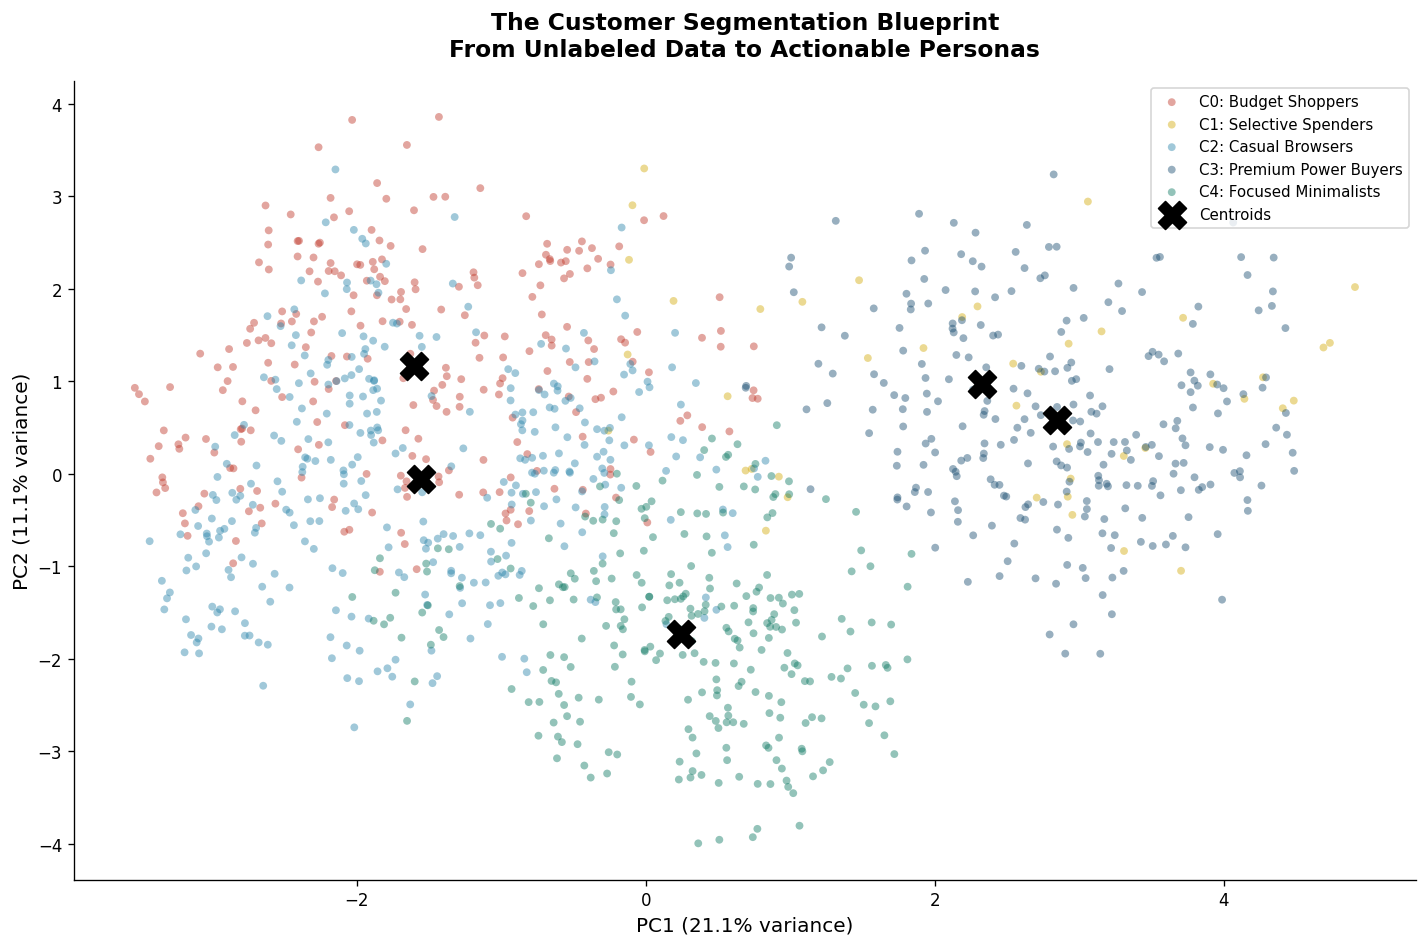

In [26]:
# Final labeled scatter with persona names
fig, ax = plt.subplots(figsize=(12, 8))

for c in range(BEST_K):
    mask = df['Cluster'] == c
    ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
               alpha=0.45, s=22, color=PERSONAS[c]['color'],
               label=f"C{c}: {PERSONAS[c]['name']}", edgecolors='none')

ax.scatter(centroids_pca2[:, 0], centroids_pca2[:, 1],
           s=280, c='black', marker='X', zorder=6, label='Centroids')

ax.set_xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=12)
ax.set_title('The Customer Segmentation Blueprint\nFrom Unlabeled Data to Actionable Personas',
             fontweight='bold', pad=15, fontsize=14)
ax.legend(fontsize=9, loc='upper right')
plt.tight_layout()
plt.savefig('images/persona_map.png', bbox_inches='tight')
plt.show()

---
## Phase 9 — Save Results

In [27]:
output = df[['CustomerID', 'Cluster']].copy()
output['Cluster'] = output['Cluster'].astype(int)
output['Persona'] = output['Cluster'].map({c: PERSONAS[c]['name'] for c in PERSONAS})
output.to_csv('segmented_customers.csv', index=False)

print(f'Saved: segmented_customers.csv')
print(f'Rows: {len(output)}')
print()
print('Preview:')
display(output.head(10))
print()
print('Segment Distribution:')
print(output.groupby(['Cluster','Persona']).size().reset_index(name='Count'))

Saved: segmented_customers.csv
Rows: 1200

Preview:


,CustomerID,Cluster,Persona
0,C72649,3,Premium Power Buyers
1,C75739,0,Budget Shoppers
2,C81728,1,Selective Spenders
3,C33540,0,Budget Shoppers
4,C81840,3,Premium Power Buyers
5,C37249,0,Budget Shoppers
6,C83492,4,Focused Minimalists
7,C41460,2,Casual Browsers
8,C26817,2,Casual Browsers
9,C31946,3,Premium Power Buyers



Segment Distribution:
   Cluster               Persona  Count
0        0       Budget Shoppers    261
1        1    Selective Spenders     43
2        2       Casual Browsers    341
3        3  Premium Power Buyers    274
4        4   Focused Minimalists    281


---
## Summary

| Step | Method | Result |
|------|--------|--------|
| Feature Engineering | 14 raw → 20 features | Behavioral, temporal, encoded dimensions |
| Standardization | StandardScaler (z = (x−μ)/σ) | Removed scale bias for Euclidean distance |
| PCA | 95% variance threshold | 13 components from 20 features |
| Optimal K | Elbow Method + Silhouette Score | K = 5 |
| Clustering | K-Means++ (n_init=20) | 5 distinct segments |
| Silhouette Score | Final model | 0.1272 |
| Business Output | Inverse-transform centroids | 5 named personas with strategic actions |

### The 5 Customer Personas

| Cluster | Persona | Size | Avg Order | Key Insight |
|---------|---------|------|-----------|-------------|
| 0 | Budget Shoppers | 261 (21.8%) | $555 | Highest coupon use (78%), price-driven |
| 1 | Selective Spenders | 43 (3.6%) | $1,974 | High-value bulk buyers, social-proof driven |
| 2 | Casual Browsers | 341 (28.4%) | $573 | Largest segment, high cart abandonment risk |
| 3 | Premium Power Buyers | 274 (22.8%) | $2,242 | Top revenue segment, near 100% high-value |
| 4 | Focused Minimalists | 281 (23.4%) | $802 | Single-item precision buyers, high return rate |

**Tools:** Python 3 · pandas · numpy · scikit-learn · matplotlib · seaborn · kneed  
**Program:** DecodeLabs Data Science Internship — Project 3 of 3